In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                      'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/windows.parquet",
               "data/processed/windows.parquet",
               "windows.parquet",
               "/mnt/user-data/uploads/windows.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no windows.parquet found; tried {_CANDIDATES}")
w = pd.read_parquet(_src)
print(f"Loaded {_src}")
print(f"{w.shape[0]:,} windows x {w.shape[1]:,} columns")

PARTICIPANTS = sorted(w['participantId'].unique())
_PALETTE = plt.get_cmap('tab20').colors
_PCOLOR = {p: _PALETTE[i % len(_PALETTE)] for i, p in enumerate(PARTICIPANTS)}
def pcolor(p):
    return _PCOLOR.get(p, '0.5')

METADATA_COLS = [c for c in w.columns if c.endswith(('_afforded', '_observed', '_straddle_conflict'))] + \
    ['sessionId', 'participantId', 'deviceFamily', 'window_index', 'window_start_s', 'window_end_s',
     'taskIndex', 'taskType', 'activeArea', 'task_pass', 'task_start_s', 'task_end_s', 'task_boundary_straddle']
FAMILIES = {
    'typing':   [c for c in w.columns if c.startswith('typing_') and c not in METADATA_COLS],
    'tap':      [c for c in w.columns if c.startswith('tap_') and c not in METADATA_COLS],
    'gesture':  [c for c in w.columns if c.startswith('gesture_') and c not in METADATA_COLS],
    'coupling': [c for c in w.columns if c.startswith('coupling_')],
    'motion':   [c for c in w.columns if c.startswith('motion_')],
}
N_FEATURE_COLS = sum(len(v) for v in FAMILIES.values())
print(f"\n{len(PARTICIPANTS)} participants, {N_FEATURE_COLS} behavioural feature columns "
      f"across {len(FAMILIES)} families")


Loaded ../../data/processed/windows.parquet
2,962 windows x 617 columns

17 participants, 574 behavioural feature columns across 5 families


In [2]:
df = w
df

,sessionId,participantId,deviceFamily,window_index,window_start_s,window_end_s,deviceModel,devicePlatform,appVersion,consentVersion,schemaVersion,identitySource,usableForSignalExtraction,completedNormally,sessionIndex,sessionDurationMs,ctxTimeOfDay,ctxFatigue,ctxFocusLevel,ctxEnvironmentNoise,ctxMovement,ctxPosture,ctxHandUse,ctxInputDevice,ctxCaffeine,ctxAlcohol,ctxPrivacy,taskIndex,taskType,activeArea,...,motion_idle_run_max_len_s,motion_idle_sway_power,motion_idle_tremor_power,motion_idle_accel_mag_mean,motion_idle_accel_mag_std,motion_idle_accel_mag_median,motion_idle_accel_mag_iqr,motion_idle_accel_mag_p95,motion_idle_accel_mag_max,motion_idle_accel_mag_n,motion_idle_accel_mag_cv,motion_idle_accel_mag_slope,motion_active_accel_mag_mean,motion_active_accel_mag_std,motion_active_accel_mag_median,motion_active_accel_mag_iqr,motion_active_accel_mag_p95,motion_active_accel_mag_max,motion_active_accel_mag_n,motion_active_accel_mag_cv,motion_active_accel_mag_slope,motion_cross_axis_corr_mean,motion_cross_axis_corr_std,motion_cross_axis_corr_median,motion_cross_axis_corr_iqr,motion_cross_axis_corr_p95,motion_cross_axis_corr_max,motion_cross_axis_corr_n,motion_cross_axis_corr_cv,motion_cross_axis_corr_slope
0,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,0,0.001,15.001,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,NaN,None,None,...,2.20,NaN,NaN,0.943619,0.539846,0.903702,0.715753,1.869589,2.574084,44.0,0.572101,-0.473420,0.379458,0.314167,0.295288,0.331204,0.955498,1.997823,224.0,0.827937,-0.023576,-0.196720,0.422252,-0.150393,0.840539,0.391324,0.421914,231.0,2.146462,-0.077261
1,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,1,7.501,22.501,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,1.0,tap_account,home,...,1.25,NaN,NaN,0.283899,0.131527,0.305836,0.187533,0.411030,0.662913,25.0,0.463286,0.125351,0.386837,0.514059,0.240932,0.335125,0.930812,3.732556,218.0,1.328878,0.024969,-0.534261,0.270052,-0.597827,0.156888,0.103548,0.421914,238.0,0.505468,-0.025093
2,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,2,15.001,30.001,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,2.0,home_explore,home,...,1.25,NaN,NaN,0.283899,0.131527,0.305836,0.187533,0.411030,0.662913,25.0,0.463286,0.125351,0.598681,0.601501,0.419834,0.523975,1.711720,3.732556,212.0,1.004710,0.006080,-0.709677,0.129685,-0.739869,0.232101,-0.549524,-0.403638,235.0,0.182739,-0.021475
3,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,3,22.501,37.501,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,3.0,typing_search,activity,...,0.10,NaN,NaN,0.105814,0.059660,0.105814,0.059660,0.159508,0.165474,2.0,0.563814,NaN,0.494169,0.431488,0.371611,0.427490,1.406838,2.289117,198.0,0.873160,-0.044054,-0.659440,0.273348,-0.755419,0.213396,0.061671,0.273352,198.0,0.414516,0.046517
4,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,4,30.001,45.001,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,3.0,typing_search,activity,...,1.55,NaN,NaN,0.103796,0.090618,0.069079,0.100285,0.217130,0.460397,45.0,0.873035,0.011886,0.296588,0.310418,0.202047,0.241293,0.997558,1.823113,150.0,1.046631,0.006239,-0.507017,0.370412,-0.617775,0.590742,0.133106,0.273352,192.0,0.730572,-0.019561
...,...,...,...,...,...,...,...,...,...,...,...,..

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes.value_counts())

print("\nColumns:")
print(df.columns.tolist())

Shape: (2962, 617)

First 5 rows:


,sessionId,participantId,deviceFamily,window_index,window_start_s,window_end_s,deviceModel,devicePlatform,appVersion,consentVersion,schemaVersion,identitySource,usableForSignalExtraction,completedNormally,sessionIndex,sessionDurationMs,ctxTimeOfDay,ctxFatigue,ctxFocusLevel,ctxEnvironmentNoise,ctxMovement,ctxPosture,ctxHandUse,ctxInputDevice,ctxCaffeine,ctxAlcohol,ctxPrivacy,taskIndex,taskType,activeArea,...,motion_idle_run_max_len_s,motion_idle_sway_power,motion_idle_tremor_power,motion_idle_accel_mag_mean,motion_idle_accel_mag_std,motion_idle_accel_mag_median,motion_idle_accel_mag_iqr,motion_idle_accel_mag_p95,motion_idle_accel_mag_max,motion_idle_accel_mag_n,motion_idle_accel_mag_cv,motion_idle_accel_mag_slope,motion_active_accel_mag_mean,motion_active_accel_mag_std,motion_active_accel_mag_median,motion_active_accel_mag_iqr,motion_active_accel_mag_p95,motion_active_accel_mag_max,motion_active_accel_mag_n,motion_active_accel_mag_cv,motion_active_accel_mag_slope,motion_cross_axis_corr_mean,motion_cross_axis_corr_std,motion_cross_axis_corr_median,motion_cross_axis_corr_iqr,motion_cross_axis_corr_p95,motion_cross_axis_corr_max,motion_cross_axis_corr_n,motion_cross_axis_corr_cv,motion_cross_axis_corr_slope
0,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,0,0.001,15.001,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,NaN,None,None,...,2.20,NaN,NaN,0.943619,0.539846,0.903702,0.715753,1.869589,2.574084,44.0,0.572101,-0.473420,0.379458,0.314167,0.295288,0.331204,0.955498,1.997823,224.0,0.827937,-0.023576,-0.196720,0.422252,-0.150393,0.840539,0.391324,0.421914,231.0,2.146462,-0.077261
1,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,1,7.501,22.501,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,1.0,tap_account,home,...,1.25,NaN,NaN,0.283899,0.131527,0.305836,0.187533,0.411030,0.662913,25.0,0.463286,0.125351,0.386837,0.514059,0.240932,0.335125,0.930812,3.732556,218.0,1.328878,0.024969,-0.534261,0.270052,-0.597827,0.156888,0.103548,0.421914,238.0,0.505468,-0.025093
2,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,2,15.001,30.001,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,2.0,home_explore,home,...,1.25,NaN,NaN,0.283899,0.131527,0.305836,0.187533,0.411030,0.662913,25.0,0.463286,0.125351,0.598681,0.601501,0.419834,0.523975,1.711720,3.732556,212.0,1.004710,0.006080,-0.709677,0.129685,-0.739869,0.232101,-0.549524,-0.403638,235.0,0.182739,-0.021475
3,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,3,22.501,37.501,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,3.0,typing_search,activity,...,0.10,NaN,NaN,0.105814,0.059660,0.105814,0.059660,0.159508,0.165474,2.0,0.563814,NaN,0.494169,0.431488,0.371611,0.427490,1.406838,2.289117,198.0,0.873160,-0.044054,-0.659440,0.273348,-0.755419,0.213396,0.061671,0.273352,198.0,0.414516,0.046517
4,04c75fb82aca415db10da08431699afc,pEAB9GS,mobile,4,30.001,45.001,iphone_17e,iphone,exploratory_bank_app_v5_deployment_consent,p2_consent_2026_06_30,1.2.0,localStorage_p2_returning,True,True,3,215468,morning,5,4,quiet,none,sitting,one_handed_left,touch,none,none,private,3.0,typing_search,activity,...,1.55,NaN,NaN,0.103796,0.090618,0.069079,0.100285,0.217130,0.460397,45.0,0.873035,0.011886,0.296588,0.310418,0.202047,0.241293,0.997558,1.823113,150.0,1.046631,0.006239,-0.507017,0.370412,-0.617775,0.590742,0.133106,0.273352,192.0,0.730572,-0.019561



Data types:


float64    580
object      20
bool         6
boolean      6
int64        5
Name: count, dtype: int64


Columns:
['sessionId', 'participantId', 'deviceFamily', 'window_index', 'window_start_s', 'window_end_s', 'deviceModel', 'devicePlatform', 'appVersion', 'consentVersion', 'schemaVersion', 'identitySource', 'usableForSignalExtraction', 'completedNormally', 'sessionIndex', 'sessionDurationMs', 'ctxTimeOfDay', 'ctxFatigue', 'ctxFocusLevel', 'ctxEnvironmentNoise', 'ctxMovement', 'ctxPosture', 'ctxHandUse', 'ctxInputDevice', 'ctxCaffeine', 'ctxAlcohol', 'ctxPrivacy', 'taskIndex', 'taskType', 'activeArea', 'task_pass', 'task_start_s', 'task_end_s', 'typing_afforded', 'tapping_afforded', 'scrolling_afforded', 'typing_observed', 'tapping_observed', 'scrolling_observed', 'task_boundary_straddle', 'typing_straddle_conflict', 'tapping_straddle_conflict', 'scrolling_straddle_conflict', 'typing_keydown_count', 'typing_backspace_share', 'typing_autorepeat_share', 'typing_share_letter', 'typing_share_space', 'typing_share_backspace', 'typing_share_digit', 'typing_share_punct_or_symbol', 'typing_shar

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2962 entries, 0 to 2961
Columns: 617 entries, sessionId to motion_cross_axis_corr_slope
dtypes: bool(6), boolean(6), float64(580), int64(5), object(20)
memory usage: 13.7+ MB


In [5]:
display(
    df.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sessionId,2962,81,403e8f08544c47b083f7dde8490cd145,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
participantId,2962,17,p95MPVX,575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deviceFamily,2962,2,mobile,2912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_index,2962.0,NaN,NaN,NaN,24.907157,23.463952,0.0,9.0,19.0,32.0,130.0
window_start_s,2962.0,NaN,NaN,NaN,186.836244,175.98191,0.001,67.52125,142.5015,240.044,975.045
...,...,...,...,...,...,...,...,...,...,...,...
motion_cross_axis_corr_p95,2833.0,NaN,NaN,NaN,0.699742,0.295758,-0.804014,0.625671,0.804005,0.895902,0.99897
motion_cross_axis_corr_max,2833.0,NaN,NaN,NaN,0.748143,0.2668,-0.760207,0.696781,0.8413,0.915722,0.999047
motion_cross_axis_corr_n,2833.0,NaN,NaN,NaN,199.829156,59.118362,4.0,160.0,204.0,250.0,292.0
motion_cross_axis_corr_cv,2833.0,NaN,NaN,NaN,3.868714,73.791377,0.000124,0.248414,0.490845,1.145129,3824.450321


In [6]:
for col in df.columns:
    print(
        f"{col:50} "
        f"unique={df[col].nunique(dropna=True):5} "
        f"dtype={str(df[col].dtype):10}"
    )

sessionId                                          unique=   81 dtype=object    
participantId                                      unique=   17 dtype=object    
deviceFamily                                       unique=    2 dtype=object    
window_index                                       unique=  131 dtype=int64     
window_start_s                                     unique= 1590 dtype=float64   
window_end_s                                       unique= 1590 dtype=float64   
deviceModel                                        unique=   10 dtype=object    
devicePlatform                                     unique=    3 dtype=object    
appVersion                                         unique=    1 dtype=object    
consentVersion                                     unique=    1 dtype=object    
schemaVersion                                      unique=    1 dtype=object    
identitySource                                     unique=    1 dtype=object    
usableForSignalExtraction   

In [7]:
user_counts = df["participantId"].value_counts()

display(user_counts)

participantId
p95MPVX    575
pH3S4X4    559
p3YDMHG    333
pG5G4MS    226
pNDG8LJ    201
pUNKH7L    200
pAFQRTM    131
p3M6E7Z    126
pA6XL23    122
pEZVKTS    101
pWS9VTN     86
pWJGKPK     81
pEAB9GS     78
pZMC82M     57
pCTJ44P     36
pG2C8BC     27
pCURDWC     23
Name: count, dtype: int64

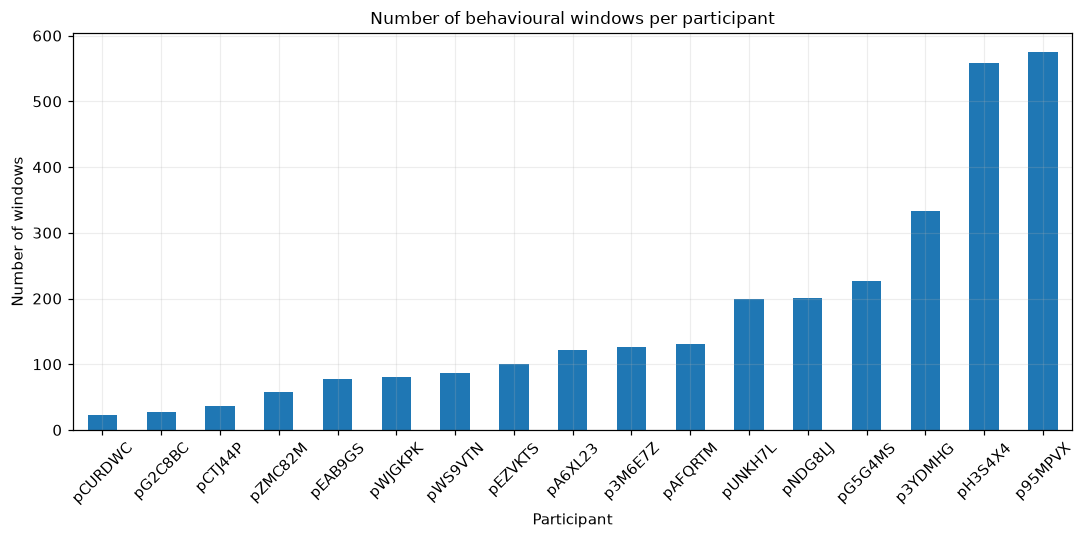

In [8]:
plt.figure(figsize=(10, 5))

user_counts.sort_values().plot(kind="bar")

plt.xlabel("Participant")
plt.ylabel("Number of windows")
plt.title("Number of behavioural windows per participant")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [9]:
user_share = (
    df["participantId"]
    .value_counts(normalize=True)
    .mul(100)
)

display(user_share)

participantId
p95MPVX    19.412559
pH3S4X4    18.872384
p3YDMHG    11.242404
pG5G4MS     7.629980
pNDG8LJ     6.785955
pUNKH7L     6.752194
pAFQRTM     4.422687
p3M6E7Z     4.253883
pA6XL23     4.118839
pEZVKTS     3.409858
pWS9VTN     2.903444
pWJGKPK     2.734639
pEAB9GS     2.633356
pZMC82M     1.924375
pCTJ44P     1.215395
pG2C8BC     0.911546
pCURDWC     0.776502
Name: proportion, dtype: float64

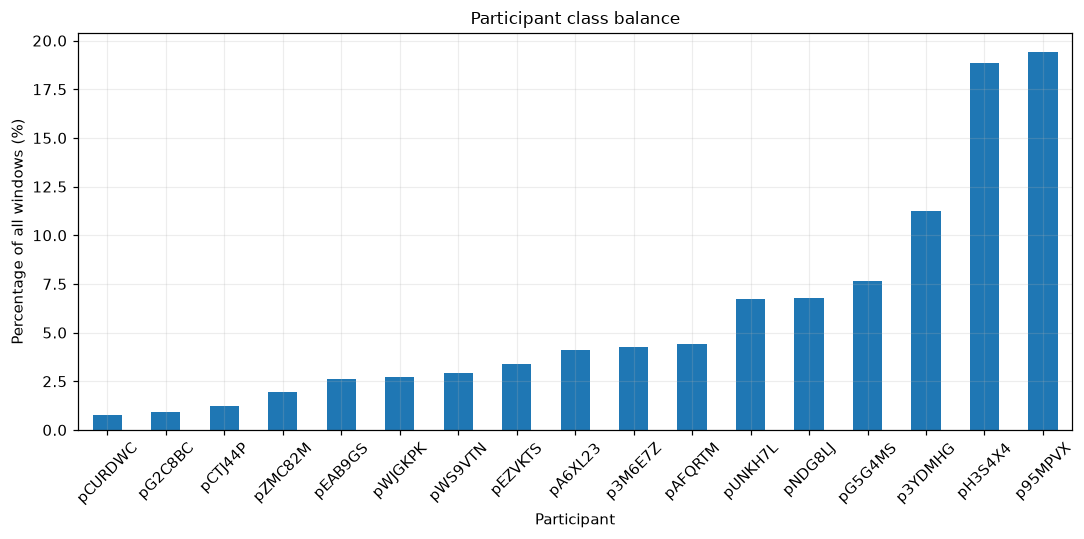

In [10]:
plt.figure(figsize=(10, 5))

user_share.sort_values().plot(kind="bar")

plt.xlabel("Participant")
plt.ylabel("Percentage of all windows (%)")
plt.title("Participant class balance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
sessions_per_user = (
    df.groupby("participantId")["sessionId"]
    .nunique()
    .sort_values()
)

display(sessions_per_user)

participantId
p3M6E7Z     1
pWJGKPK     1
pG2C8BC     1
pCURDWC     1
pCTJ44P     1
pZMC82M     1
pWS9VTN     2
pAFQRTM     2
pEAB9GS     3
pUNKH7L     3
pA6XL23     4
pEZVKTS     4
pNDG8LJ     6
p3YDMHG    10
pH3S4X4    12
p95MPVX    14
pG5G4MS    15
Name: sessionId, dtype: int64

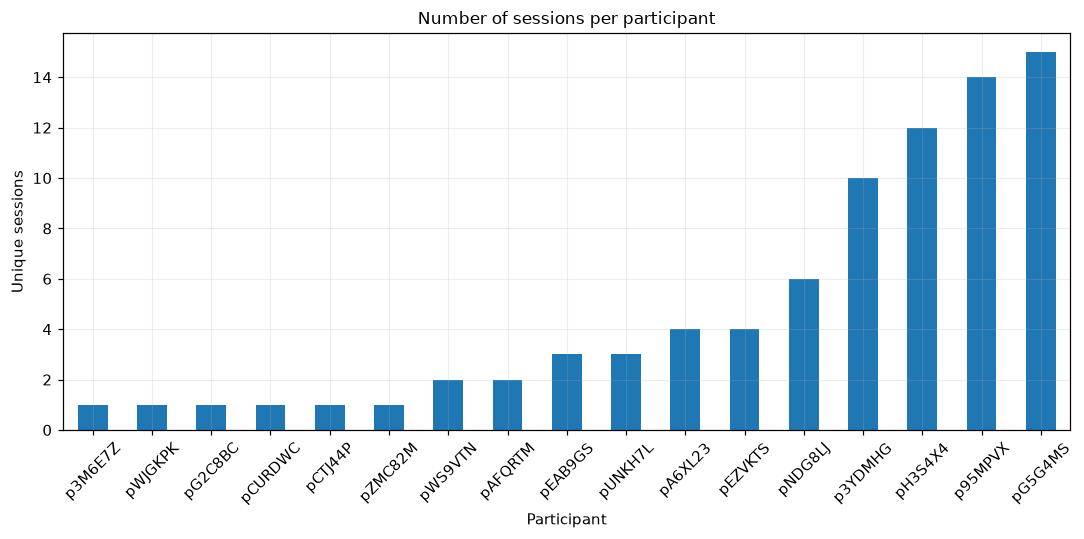

In [12]:
plt.figure(figsize=(10, 5))

sessions_per_user.plot(kind="bar")

plt.xlabel("Participant")
plt.ylabel("Unique sessions")
plt.title("Number of sessions per participant")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [13]:
windows_per_session = (
    df.groupby(["participantId", "sessionId"])
    .size()
    .rename("n_windows")
    .reset_index()
)

display(windows_per_session)

,participantId,sessionId,n_windows
0,p3M6E7Z,d8efac44560c4faaba639beb6d1cbfca,126
1,p3YDMHG,084bc1a1666a44ca9cbf7cb96afc6faf,24
2,p3YDMHG,132afaaa28fc451587d0b238cd950bbe,29
3,p3YDMHG,181ec691b99545e591e4bc727fb6bd68,26
4,p3YDMHG,1c0986bb3ad8462292990cb030bb0db5,38
...,...,...,...
76,pUNKH7L,f7309697facd4ea6885b5b3f3d5e744f,23
77,pWJGKPK,7053d39b0267423298174f439f3ca5fc,81
78,pWS9VTN,68c94e6ce33a42538f81217fa7beb07f,33
79,pWS9VTN,96a3aebbf58b4b77a74be5c69f3b8b05,53


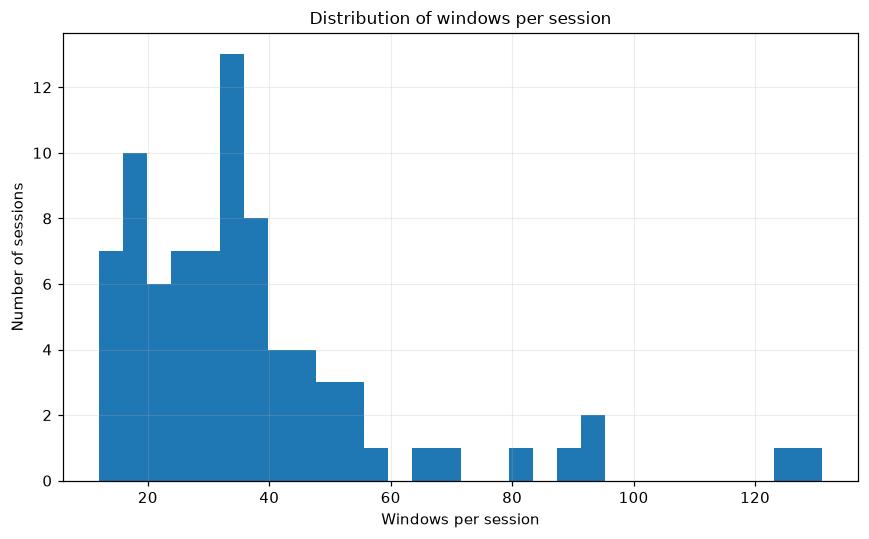

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    windows_per_session["n_windows"],
    bins=30
)

plt.xlabel("Windows per session")
plt.ylabel("Number of sessions")
plt.title("Distribution of windows per session")

plt.tight_layout()
plt.show()

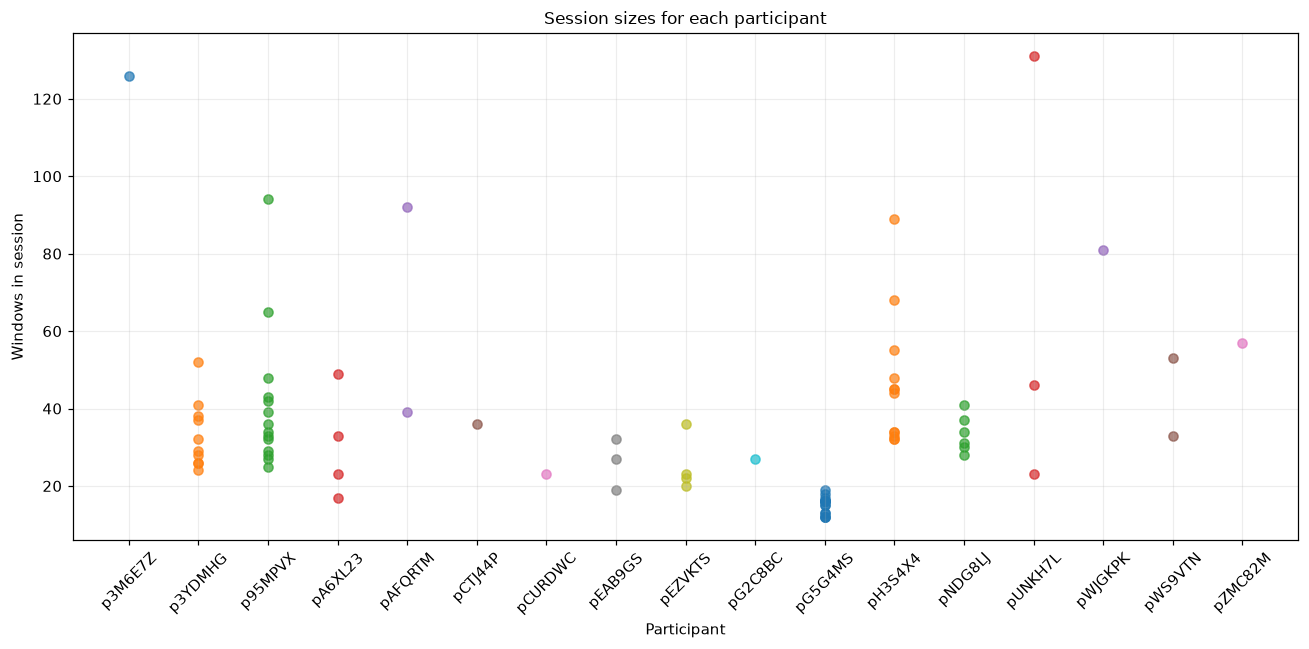

In [15]:
session_counts = (
    df.groupby(["participantId", "sessionId"])
    .size()
    .reset_index(name="n_windows")
)

plt.figure(figsize=(12, 6))

for participant, group in session_counts.groupby("participantId"):
    plt.scatter(
        [participant] * len(group),
        group["n_windows"],
        alpha=0.7
    )

plt.xlabel("Participant")
plt.ylabel("Windows in session")
plt.title("Session sizes for each participant")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [66]:
device_counts = df["deviceModel"].value_counts()
display(device_counts)

participant_device = (
    df.groupby("participantId")
    .agg(
        deviceModel=("deviceModel", "first"),
        deviceFamily=("deviceFamily", "first"),
        n_sessions=("sessionId", "nunique"),
        n_windows=("deviceModel", "count"),
    )
)
participant_device["participants_sharing_model"] = participant_device["deviceModel"].map(
    df.drop_duplicates("participantId").groupby("deviceModel")["participantId"].nunique()
)
participant_device["is_singleton_model"] = participant_device["participants_sharing_model"] == 1
participant_device = participant_device.sort_values(["deviceModel", "participantId"])
display(participant_device)

deviceModel
older_iphone                 942
iphone_13_13_mini            760
iphone_16_plus               685
iphone_17e                   159
iphone_16                    122
google_pixel_standard        101
iphone_13_pro_pro_max         86
iphone_15                     57
windows_laptop_with_mouse     27
macbook_trackpad              23
Name: count, dtype: int64

,deviceModel,deviceFamily,n_sessions,n_windows,participants_sharing_model,is_singleton_model
participantId,,,,,,
pEZVKTS,google_pixel_standard,mobile,4,101,1,True
pH3S4X4,iphone_13_13_mini,mobile,12,559,2,False
pNDG8LJ,iphone_13_13_mini,mobile,6,201,2,False
pWS9VTN,iphone_13_pro_pro_max,mobile,2,86,1,True
pZMC82M,iphone_15,mobile,1,57,1,True
pA6XL23,iphone_16,mobile,4,122,1,True
p3M6E7Z,iphone_16_plus,mobile,1,126,3,False
p3YDMHG,iphone_16_plus,mobile,10,333,3,False
pG5G4MS,iphone_16_plus,mobile,15,226,3,False


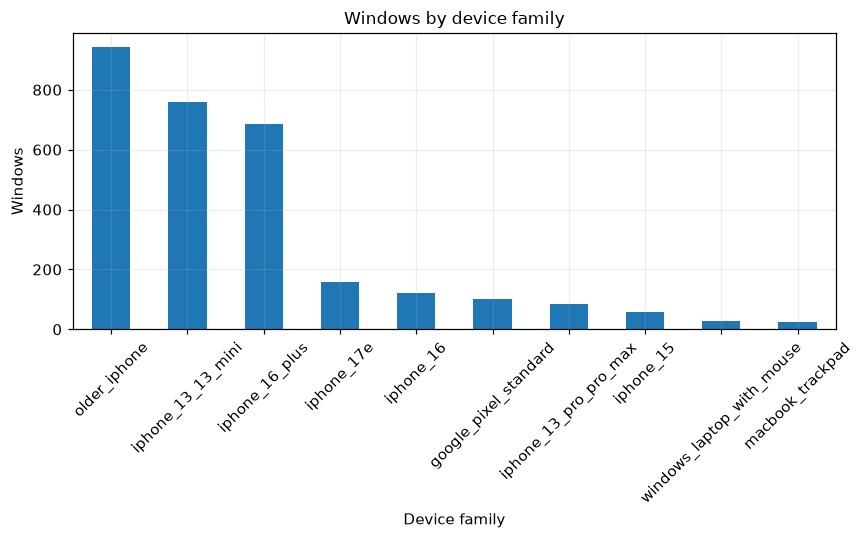

In [17]:
plt.figure(figsize=(8, 5))

device_counts.plot(kind="bar")

plt.xlabel("Device family")
plt.ylabel("Windows")
plt.title("Windows by device family")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
user_device = pd.crosstab(
    df["participantId"],
    df["deviceModel"]
)

display(user_device)

deviceModel,google_pixel_standard,iphone_13_13_mini,iphone_13_pro_pro_max,iphone_15,iphone_16,iphone_16_plus,iphone_17e,macbook_trackpad,older_iphone,windows_laptop_with_mouse
participantId,,,,,,,,,,
p3M6E7Z,0,0,0,0,0,126,0,0,0,0
p3YDMHG,0,0,0,0,0,333,0,0,0,0
p95MPVX,0,0,0,0,0,0,0,0,575,0
pA6XL23,0,0,0,0,122,0,0,0,0,0
pAFQRTM,0,0,0,0,0,0,0,0,131,0
pCTJ44P,0,0,0,0,0,0,0,0,36,0
pCURDWC,0,0,0,0,0,0,0,23,0,0
pEAB9GS,0,0,0,0,0,0,78,0,0,0
pEZVKTS,101,0,0,0,0,0,0,0,0,0


In [19]:
user_device_pct = (
    pd.crosstab(
        df["participantId"],
        df["deviceModel"],
        normalize="index"
    )
    * 100
)

display(user_device_pct.round(1))

deviceModel,google_pixel_standard,iphone_13_13_mini,iphone_13_pro_pro_max,iphone_15,iphone_16,iphone_16_plus,iphone_17e,macbook_trackpad,older_iphone,windows_laptop_with_mouse
participantId,,,,,,,,,,
p3M6E7Z,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
p3YDMHG,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
p95MPVX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0
pA6XL23,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0
pAFQRTM,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0
pCTJ44P,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0
pCURDWC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
pEAB9GS,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
pEZVKTS,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


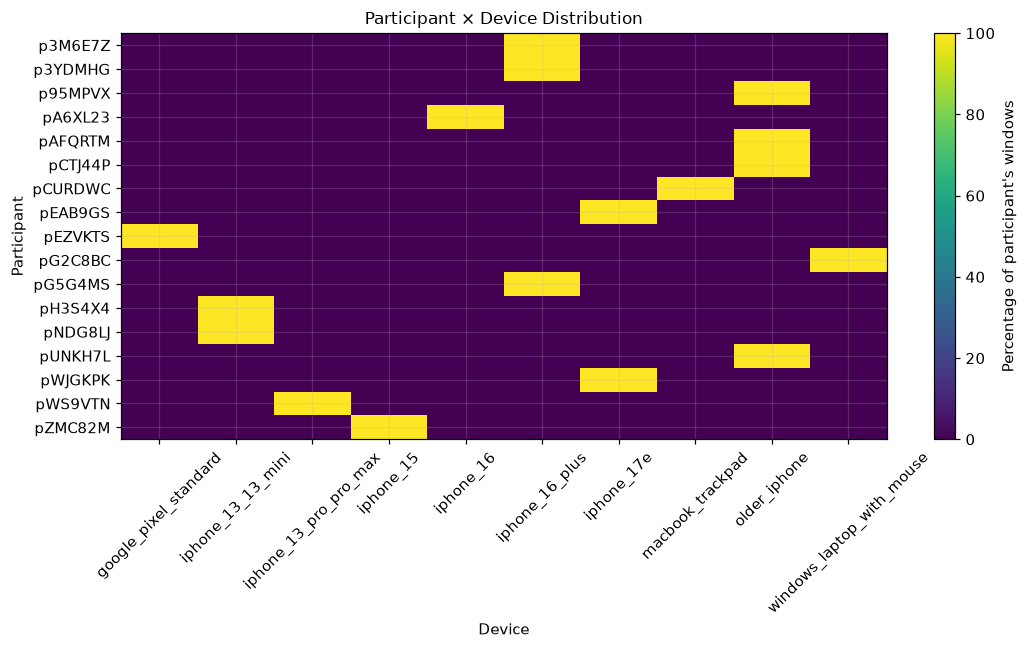

In [20]:
plt.figure(figsize=(10, 6))

plt.imshow(
    user_device_pct,
    aspect="auto"
)

plt.colorbar(label="Percentage of participant's windows")

plt.xticks(
    range(len(user_device_pct.columns)),
    user_device_pct.columns,
    rotation=45
)

plt.yticks(
    range(len(user_device_pct.index)),
    user_device_pct.index
)

plt.xlabel("Device")
plt.ylabel("Participant")
plt.title("Participant × Device Distribution")

plt.tight_layout()
plt.show()

In [21]:
devices_per_user = (
    df.groupby("participantId")["deviceModel"]
    .nunique()
    .sort_values()
)

display(devices_per_user)

participantId
p3M6E7Z    1
pWJGKPK    1
pUNKH7L    1
pNDG8LJ    1
pH3S4X4    1
pG5G4MS    1
pG2C8BC    1
pWS9VTN    1
pEZVKTS    1
pCURDWC    1
pCTJ44P    1
pAFQRTM    1
pA6XL23    1
p95MPVX    1
p3YDMHG    1
pEAB9GS    1
pZMC82M    1
Name: deviceModel, dtype: int64

In [22]:
task_cols = [
    col for col in df.columns
    if any(
        word in col.lower()
        for word in ["task", "game", "activity", "mode"]
    )
]

print(task_cols)

['deviceModel', 'taskIndex', 'taskType', 'task_pass', 'task_start_s', 'task_end_s', 'task_boundary_straddle']


In [23]:
for col in task_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))


--- deviceModel ---
deviceModel
older_iphone                 942
iphone_13_13_mini            760
iphone_16_plus               685
iphone_17e                   159
iphone_16                    122
google_pixel_standard        101
iphone_13_pro_pro_max         86
iphone_15                     57
windows_laptop_with_mouse     27
macbook_trackpad              23
Name: count, dtype: int64

--- taskIndex ---
taskIndex
3.0     291
14.0    250
13.0    227
5.0     190
16.0    177
22.0    157
7.0     135
9.0     128
2.0     111
6.0     110
17.0    103
18.0    103
1.0     102
10.0     99
20.0     96
11.0     86
8.0      84
24.0     84
NaN      81
21.0     77
Name: count, dtype: int64

--- taskType ---
taskType
typing_search       541
transaction_feed    367
guided_reply        311
insights_review     243
guided_note         238
pots_transfer       224
categorise          213
card_swipe          176
pot_drag            142
activity_filter     119
home_explore        111
tap_account         102
N

In [24]:
task_counts = df["taskType"].value_counts()

display(task_counts)

taskType
typing_search       541
transaction_feed    367
guided_reply        311
insights_review     243
guided_note         238
pots_transfer       224
categorise          213
card_swipe          176
pot_drag            142
activity_filter     119
home_explore        111
tap_account         102
swipe_approval       78
code                 15
finish                1
Name: count, dtype: int64

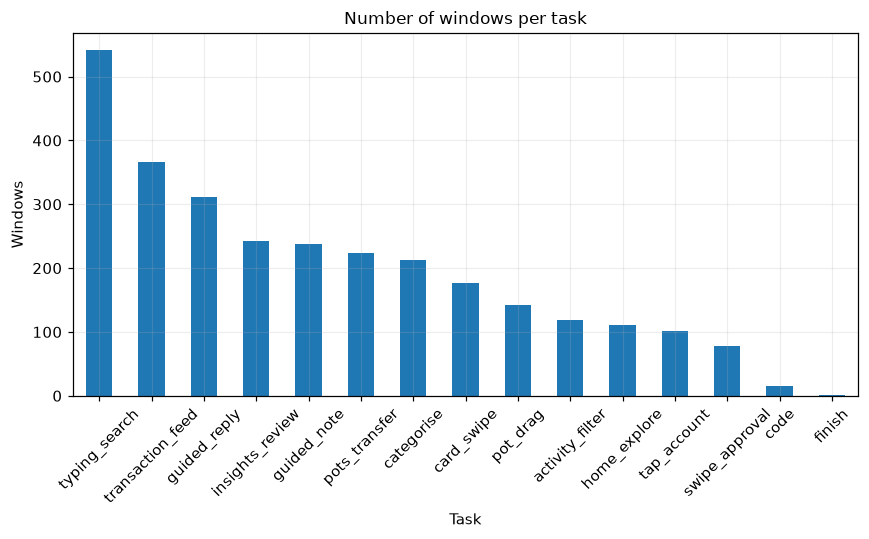

In [25]:
plt.figure(figsize=(8, 5))

task_counts.plot(kind="bar")

plt.xlabel("Task")
plt.ylabel("Windows")
plt.title("Number of windows per task")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [26]:
user_task = pd.crosstab(
    df["participantId"],
    df["taskType"],
    normalize="index"
) * 100

display(user_task.round(1))

taskType,activity_filter,card_swipe,categorise,code,finish,guided_note,guided_reply,home_explore,insights_review,pot_drag,pots_transfer,swipe_approval,tap_account,transaction_feed,typing_search
participantId,,,,,,,,,,,,,,,
p3M6E7Z,7.2,4.8,4.8,0.8,0.0,13.6,17.6,3.2,2.4,4.0,4.8,1.6,4.8,8.8,21.6
p3YDMHG,3.7,7.7,7.1,0.9,0.0,9.0,14.2,3.1,5.6,4.6,7.7,3.1,4.0,11.5,17.6
p95MPVX,4.3,5.3,7.3,0.0,0.0,10.2,11.4,6.2,7.3,4.6,7.0,3.7,3.6,10.7,18.4
pA6XL23,4.2,8.5,9.3,1.7,0.0,5.9,9.3,3.4,5.1,8.5,7.6,1.7,2.5,16.9,15.3
pAFQRTM,3.9,4.7,5.4,0.8,0.8,7.0,24.8,1.6,5.4,7.0,7.8,0.8,3.1,6.2,20.9
pCTJ44P,0.0,5.7,8.6,2.9,0.0,0.0,25.7,8.6,0.0,5.7,5.7,5.7,2.9,8.6,20.0
pCURDWC,4.5,9.1,13.6,0.0,0.0,9.1,4.5,4.5,4.5,0.0,9.1,0.0,4.5,18.2,18.2
pEAB9GS,2.7,5.3,8.0,0.0,0.0,6.7,4.0,4.0,6.7,8.0,9.3,2.7,5.3,17.3,20.0
pEZVKTS,6.2,7.2,8.2,0.0,0.0,7.2,5.2,3.1,4.1,4.1,9.3,2.1,4.1,19.6,19.6


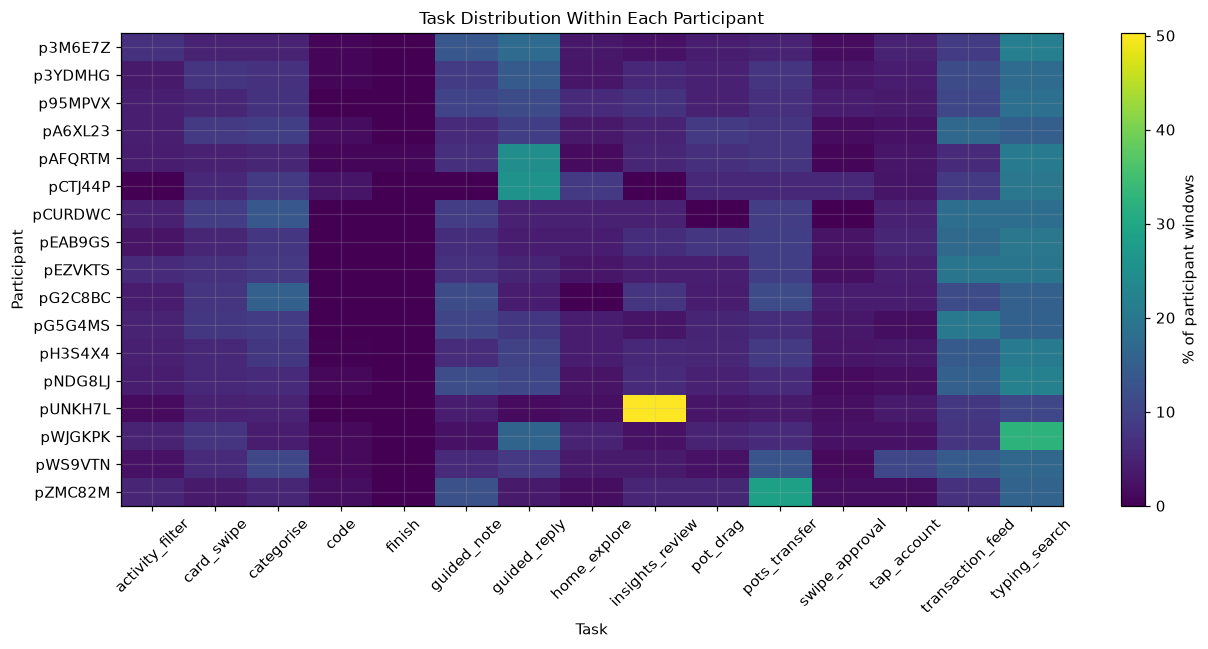

In [27]:
plt.figure(figsize=(12, 6))

plt.imshow(
    user_task,
    aspect="auto"
)

plt.colorbar(label="% of participant windows")

plt.xticks(
    range(len(user_task.columns)),
    user_task.columns,
    rotation=45
)

plt.yticks(
    range(len(user_task.index)),
    user_task.index
)

plt.xlabel("Task")
plt.ylabel("Participant")
plt.title("Task Distribution Within Each Participant")

plt.tight_layout()
plt.show()

In [28]:
feature_families = {
    "typing": [
        col for col in df.columns
        if col.startswith("typing_")
    ],

    "tap": [
        col for col in df.columns
        if col.startswith("tap_")
    ],

    "motion": [
        col for col in df.columns
        if col.startswith("motion_")
    ],

    "gesture": [
        col for col in df.columns
        if col.startswith("gesture_")
    ],

    "scroll": [
        col for col in df.columns
        if col.startswith("scroll_")
    ]
}

for family, cols in feature_families.items():
    print(f"{family:10}: {len(cols)} features")

typing    : 184 features
tap       : 59 features
motion    : 31 features
gesture   : 105 features
scroll    : 0 features


In [29]:
family_missingness = {}

for family, cols in feature_families.items():

    if len(cols) > 0:

        family_missingness[family] = (
            df[cols]
            .isna()
            .mean()
            .mean()
            * 100
        )

family_missingness = pd.Series(
    family_missingness
).sort_values()

display(family_missingness)

tap        12.155094
motion     19.435429
gesture    48.405518
typing     93.796054
dtype: float64

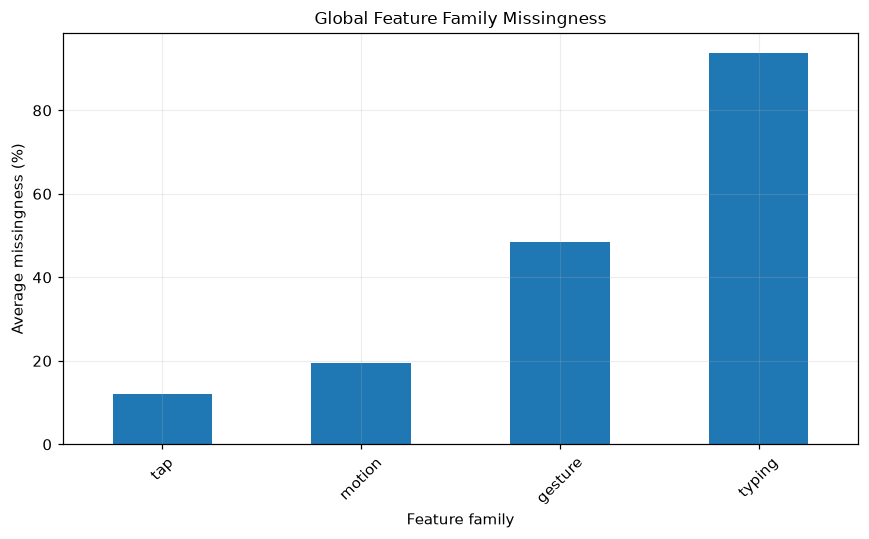

In [30]:
plt.figure(figsize=(8, 5))

family_missingness.plot(kind="bar")

plt.ylabel("Average missingness (%)")
plt.xlabel("Feature family")
plt.title("Global Feature Family Missingness")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [31]:
typing_cols = feature_families["typing"]

typing_missing_by_task = (
    df.groupby("taskType")[typing_cols]
    .apply(lambda x: x.isna().mean().mean() * 100)
    .sort_values()
)

display(typing_missing_by_task)

taskType
guided_reply        74.592828
typing_search       89.233907
guided_note         94.425923
pots_transfer       96.962345
activity_filter     98.369565
card_swipe          98.369565
categorise          98.369565
code                98.369565
finish              98.369565
home_explore        98.369565
insights_review     98.369565
pot_drag            98.369565
swipe_approval      98.369565
tap_account         98.369565
transaction_feed    98.369565
dtype: float64

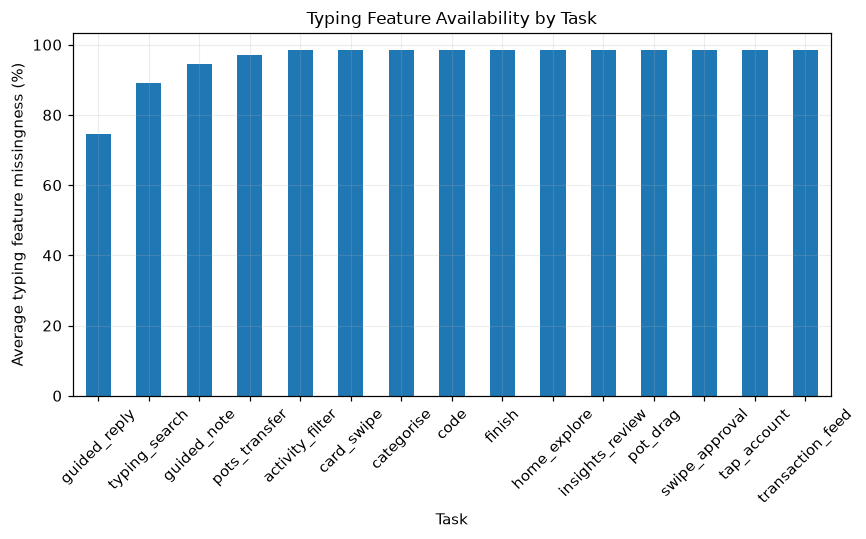

In [32]:
plt.figure(figsize=(8, 5))

typing_missing_by_task.plot(kind="bar")

plt.xlabel("Task")
plt.ylabel("Average typing feature missingness (%)")
plt.title("Typing Feature Availability by Task")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

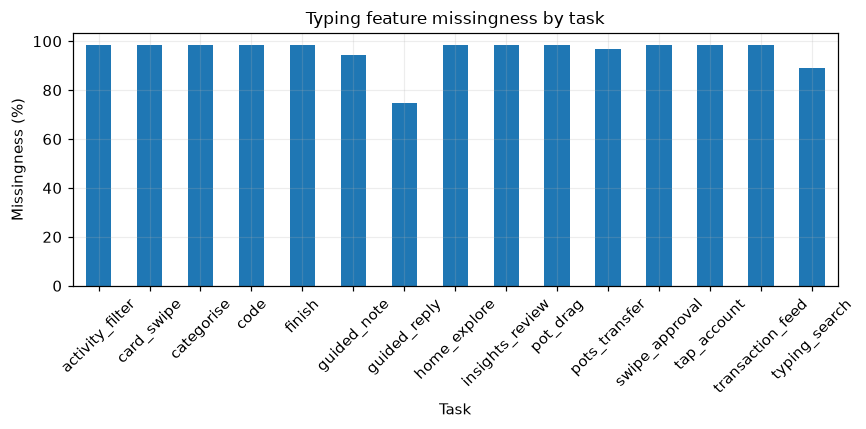

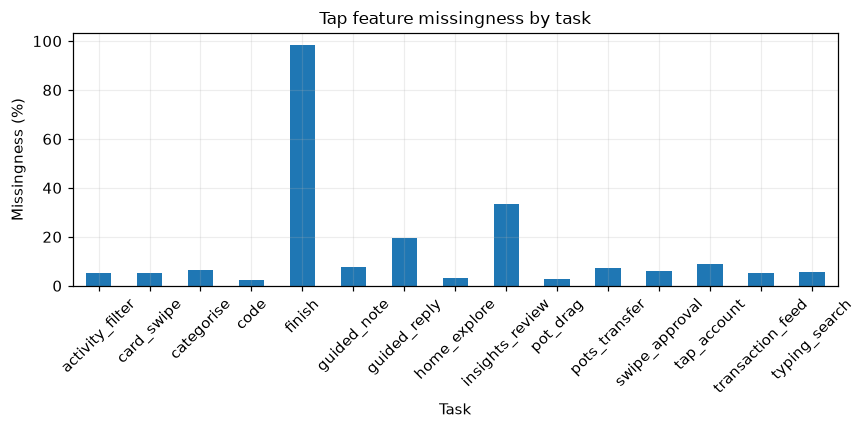

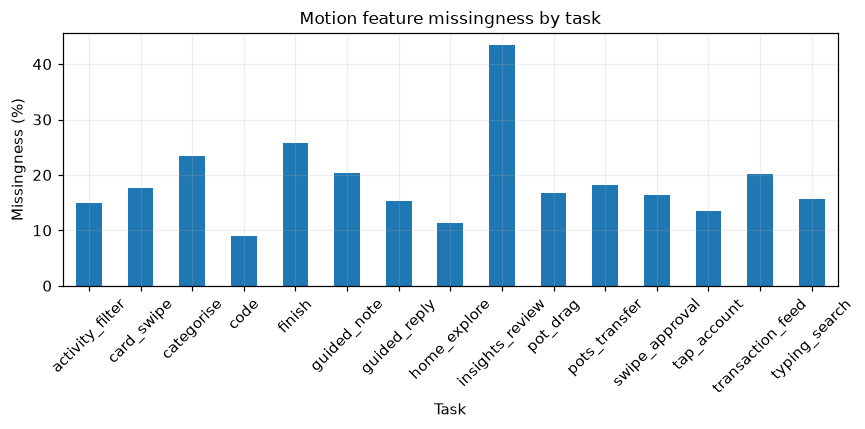

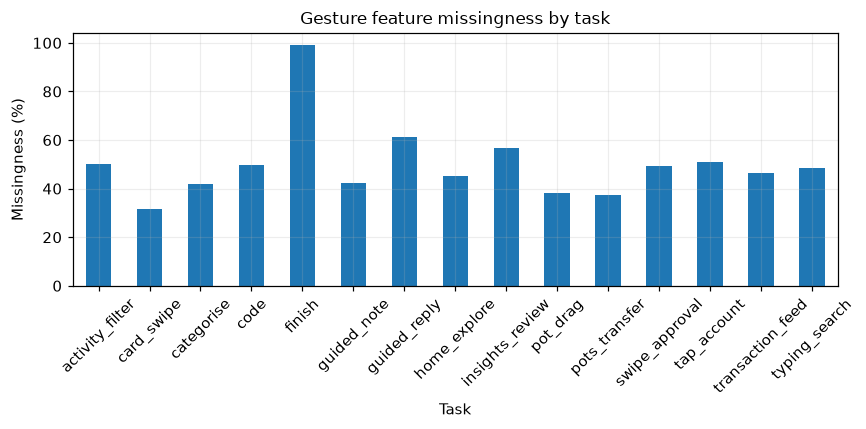

In [33]:
for family, cols in feature_families.items():

    if len(cols) == 0:
        continue

    missing_by_task = (
        df.groupby("taskType")[cols]
        .apply(lambda x: x.isna().mean().mean() * 100)
    )

    plt.figure(figsize=(8, 4))

    missing_by_task.plot(kind="bar")

    plt.title(f"{family.capitalize()} feature missingness by task")
    plt.xlabel("Task")
    plt.ylabel("Missingness (%)")

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

In [34]:
family_activity = pd.DataFrame(index=df.index)

for family, cols in feature_families.items():

    if len(cols) == 0:
        continue

    family_activity[family] = (
        df[cols]
        .notna()
        .any(axis=1)
    )

In [35]:
df["n_active_modalities"] = (
    family_activity
    .sum(axis=1)
)

display(
    df["n_active_modalities"]
    .value_counts()
    .sort_index()
)

n_active_modalities
1       2
2      79
3     127
4    2754
Name: count, dtype: int64

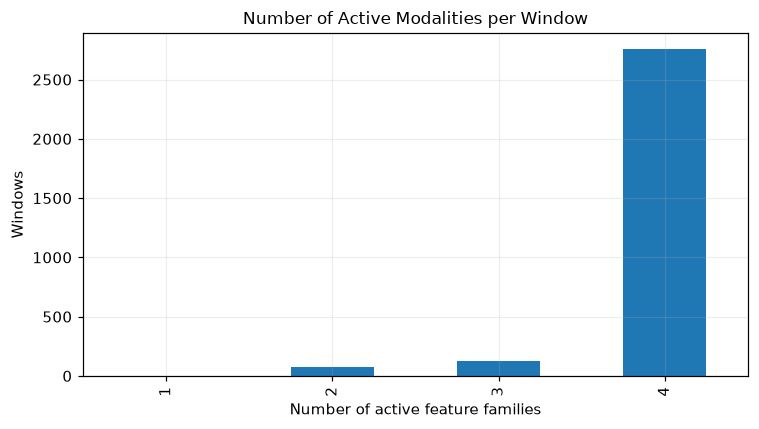

In [36]:
plt.figure(figsize=(7, 4))

df["n_active_modalities"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Number of active feature families")
plt.ylabel("Windows")
plt.title("Number of Active Modalities per Window")

plt.tight_layout()
plt.show()

In [37]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

In [38]:
feature_variance = (
    df[numeric_cols]
    .var()
    .sort_values()
)

display(feature_variance.head(20))

typing_transition_space_space_ms_n         0.000000
typing_transition_space_backspace_ms_n     0.000000
coupling_tap_accel_z_share_slope           0.000430
tap_y_slope                                0.000571
gesture_stroke_y0_slope                    0.000813
coupling_key_accel_z_share_std             0.000818
tap_x_slope                                0.001108
motion_active_accel_mag_slope              0.001112
tap_coverage                               0.001127
coupling_tap_accel_z_share_std             0.001319
gesture_stroke_x0_slope                    0.001929
motion_cross_axis_corr_slope               0.002323
coupling_key_accel_z_share_iqr             0.002598
coupling_gesture_mid_phase_energy_slope    0.002610
coupling_tap_accel_z_share_iqr             0.003118
tap_y_std                                  0.003238
gesture_scroll_fling_coast_frac_slope      0.003807
motion_idle_tremor_power                   0.003890
gesture_share_long_press                   0.004029
coupling_key

In [39]:
display(
    feature_variance[feature_variance.isna()==False].tail(20)
)

gesture_hold_scroll_fling_ms_median    2.269868e+06
gesture_hold_scroll_fling_ms_mean      2.293680e+06
gesture_hold_ms_median                 2.399409e+06
gesture_hold_ms_mean                   2.431877e+06
tap_hold_ms_max                        2.658356e+06
gesture_hold_scroll_fling_ms_p95       2.773873e+06
gesture_hold_long_press_ms_max         3.087103e+06
gesture_hold_drag_swipe_ms_mean        3.299888e+06
gesture_hold_drag_swipe_ms_median      3.376525e+06
gesture_hold_scroll_fling_ms_max       3.542837e+06
gesture_hold_drag_swipe_ms_max         4.169554e+06
gesture_hold_long_press_ms_p95         4.591016e+06
gesture_hold_ms_p95                    5.098824e+06
gesture_hold_drag_swipe_ms_p95         5.222659e+06
gesture_hold_ms_max                    5.932961e+06
gesture_hold_scroll_drag_ms_mean       6.293861e+06
gesture_hold_scroll_drag_ms_median     6.320951e+06
gesture_hold_scroll_drag_ms_max        8.508700e+06
gesture_hold_scroll_drag_ms_p95        1.425471e+07
sessionDurat

In [40]:
n_unique = df.nunique(dropna=True)

constant_cols = n_unique[
    n_unique <= 1
].index.tolist()

print("Number of constant features:", len(constant_cols))

print(constant_cols)

Number of constant features: 35
['appVersion', 'consentVersion', 'schemaVersion', 'identitySource', 'usableForSignalExtraction', 'completedNormally', 'tapping_afforded', 'scrolling_afforded', 'tapping_straddle_conflict', 'scrolling_straddle_conflict', 'typing_dwell_punct_or_symbol_ms_slope', 'typing_transition_letter_backspace_ms_slope', 'typing_transition_space_space_ms_std', 'typing_transition_space_space_ms_iqr', 'typing_transition_space_space_ms_p95', 'typing_transition_space_space_ms_n', 'typing_transition_space_space_ms_cv', 'typing_transition_space_space_ms_slope', 'typing_transition_space_backspace_ms_std', 'typing_transition_space_backspace_ms_iqr', 'typing_transition_space_backspace_ms_p95', 'typing_transition_space_backspace_ms_n', 'typing_transition_space_backspace_ms_cv', 'typing_transition_space_backspace_ms_slope', 'typing_transition_backspace_letter_ms_slope', 'typing_transition_backspace_space_ms_mean', 'typing_transition_backspace_space_ms_std', 'typing_transition_bac

In [41]:
near_constant = n_unique[
    n_unique <= 15
].sort_values()
display(near_constant)

typing_transition_space_space_ms_slope          0
typing_transition_backspace_space_ms_std        0
typing_transition_backspace_space_ms_median     0
typing_transition_space_backspace_ms_slope      0
typing_transition_space_backspace_ms_cv         0
                                               ..
typing_backspace_run_length_mean               14
tap_cells_touched                              15
tap_coverage                                   15
taskType                                       15
typing_dwell_digit_ms_median                   15
Length: 116, dtype: int64

In [42]:
display(n_unique.sort_values())

typing_transition_space_backspace_ms_slope       0
typing_transition_backspace_space_ms_mean        0
typing_transition_space_space_ms_slope           0
typing_transition_space_backspace_ms_std         0
typing_transition_space_backspace_ms_iqr         0
                                              ... 
motion_cross_axis_corr_mean                   2832
motion_cross_axis_corr_cv                     2832
motion_cross_axis_corr_iqr                    2832
motion_cross_axis_corr_std                    2832
motion_cross_axis_corr_slope                  2833
Length: 618, dtype: int64

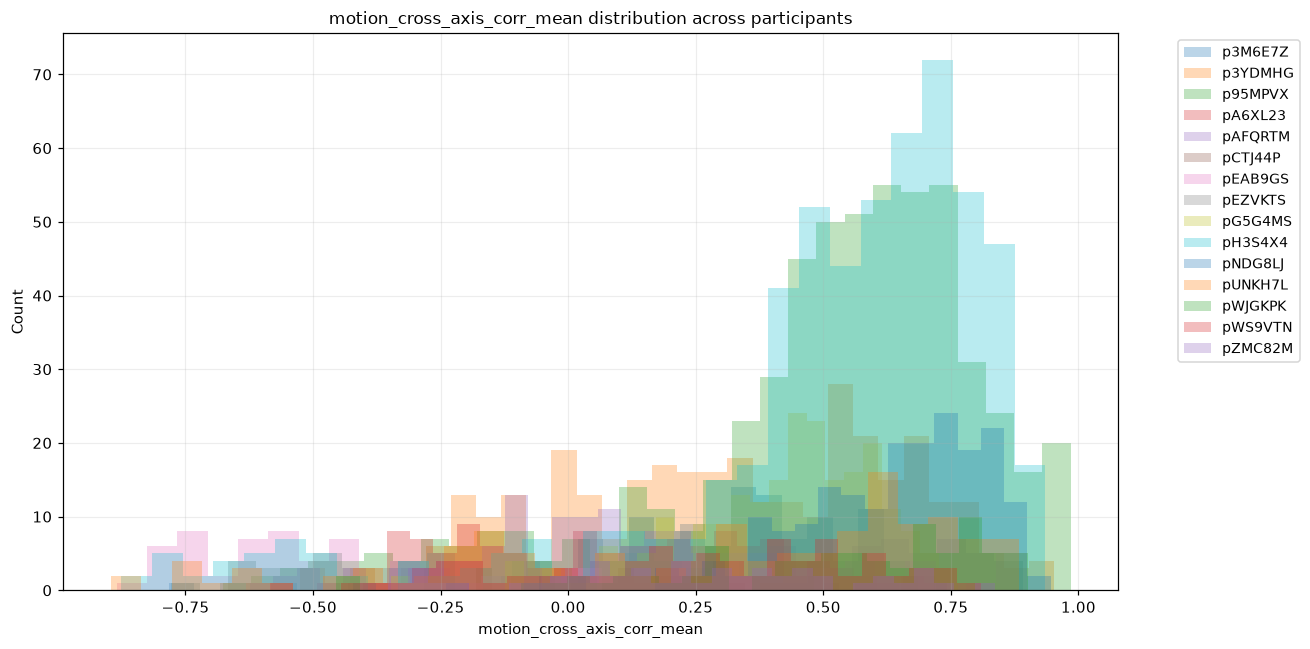

In [43]:
feature = "motion_cross_axis_corr_mean"

plt.figure(figsize=(12, 6))

for participant, group in df.groupby("participantId"):

    values = group[feature].dropna()

    if len(values) > 0:
        plt.hist(
            values,
            bins=30,
            alpha=0.3,
            label=participant
        )

plt.xlabel(feature)
plt.ylabel("Count")
plt.title(f"{feature} distribution across participants")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [44]:
feature = "motion_cross_axis_corr_mean"

user_feature_means = (
    df.groupby("participantId")[feature]
    .mean()
    .sort_values()
)

display(user_feature_means)

participantId
pEAB9GS   -0.213205
pAFQRTM    0.054442
pA6XL23    0.080779
pEZVKTS    0.183211
pWS9VTN    0.233962
pZMC82M    0.243387
pUNKH7L    0.268504
p3M6E7Z    0.270059
pCTJ44P    0.303074
p3YDMHG    0.310684
pG5G4MS    0.405298
p95MPVX    0.493347
pH3S4X4    0.501793
pWJGKPK    0.526174
pNDG8LJ    0.622761
pCURDWC         NaN
pG2C8BC         NaN
Name: motion_cross_axis_corr_mean, dtype: float64

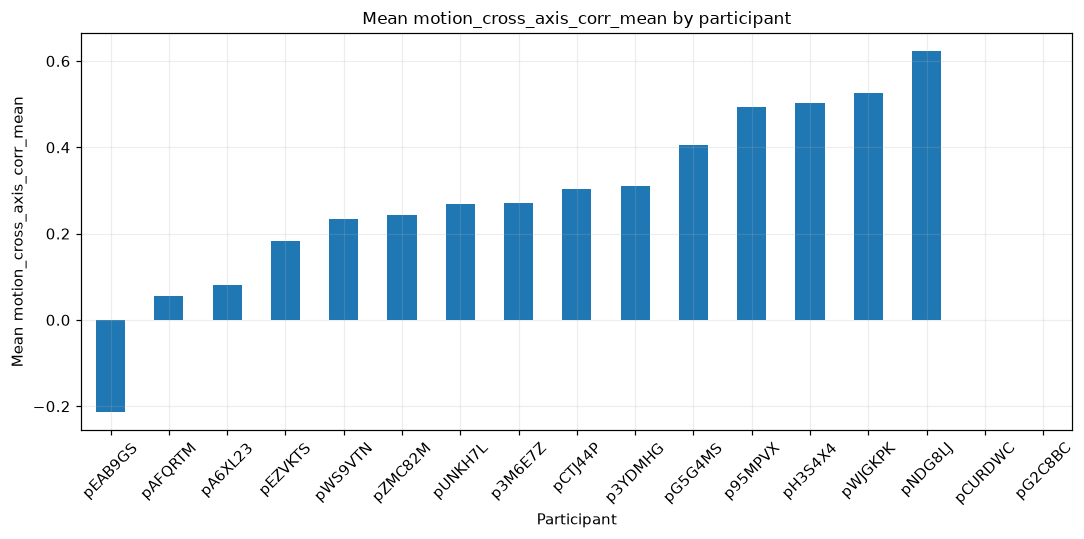

In [45]:
plt.figure(figsize=(10, 5))

user_feature_means.plot(kind="bar")

plt.xlabel("Participant")
plt.ylabel(f"Mean {feature}")
plt.title(f"Mean {feature} by participant")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [46]:


user_stats = (
    df.groupby("participantId")[feature]
    .agg(["mean", "std", "count"])
)

display(user_stats)

,mean,std,count
participantId,,,
p3M6E7Z,0.270059,0.276310,125
p3YDMHG,0.310684,0.330653,333
p95MPVX,0.493347,0.327718,568
pA6XL23,0.080779,0.290381,122
pAFQRTM,0.054442,0.280915,131
pCTJ44P,0.303074,0.267143,36
pCURDWC,NaN,NaN,0
pEAB9GS,-0.213205,0.557316,78
pEZVKTS,0.183211,0.490590,101


In [47]:
between_user_std = (
    user_stats["mean"]
    .std()
)

within_user_std = (
    user_stats["std"]
    .mean()
)

print("Between-user variation:", between_user_std)
print("Average within-user variation:", within_user_std)

print(
    "Separation ratio:",
    between_user_std / within_user_std
)

Between-user variation: 0.21320197451338047
Average within-user variation: 0.33312419451535874
Separation ratio: 0.6400074747604403


In [48]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

rows = []

for feature in numeric_cols:

    grouped = (
        df.groupby("participantId")[feature]
        .agg(["mean", "std", "count"])
    )

    between = grouped["mean"].std()
    within = grouped["std"].mean()

    if (
        pd.notna(between)
        and pd.notna(within)
        and within > 0
    ):

        rows.append({
            "feature": feature,
            "between_user_std": between,
            "within_user_std": within,
            "separation_ratio": between / within
        })

separation_df = (
    pd.DataFrame(rows)
    .sort_values(
        "separation_ratio",
        ascending=False
    )
)

display(separation_df.head(30))

,feature,between_user_std,within_user_std,separation_ratio
65,typing_dwell_digit_ms_slope,3.589618,8.692567e-15,4.129526e+14
143,typing_transition_backspace_letter_ms_p95,606.918335,1.107801e+00,5.478588e+02
137,typing_transition_space_space_ms_median,1699.743281,3.560197e+00,4.774296e+02
136,typing_transition_space_space_ms_mean,1699.743281,3.560197e+00,4.774296e+02
138,typing_transition_space_space_ms_max,1699.743281,3.560197e+00,4.774296e+02
123,typing_transition_letter_backspace_ms_p95,392.035396,3.197077e+00,1.226231e+02
205,tap_radiusY_mean,20.337605,8.003986e-01,2.540935e+01
140,typing_transition_backspace_letter_ms_std,145.801406,6.363961e+00,2.291048e+01
142,typing_transition_backspace_letter_ms_iqr,145.801406,6.363961e+00,2.291048e+01
207,tap_radiusY_median,20.077282,1.039676e+00,1.931110e+01


In [49]:
def get_family(feature):

    for family in feature_families:

        if feature.startswith(f"{family}_"):
            return family

    return "other"


separation_df["family"] = (
    separation_df["feature"]
    .apply(get_family)
)

In [50]:
family_separation = (
    separation_df
    .groupby("family")["separation_ratio"]
    .median()
    .sort_values(
        ascending=False
    )
)

display(family_separation)

family
typing     1.120320
tap        0.775150
gesture    0.690999
motion     0.480235
other      0.475640
Name: separation_ratio, dtype: float64

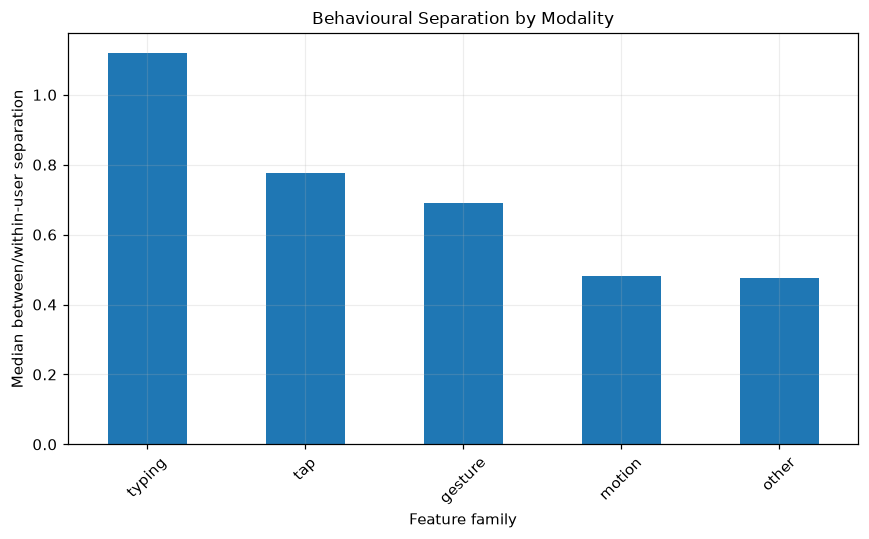

In [51]:
plt.figure(figsize=(8, 5))

family_separation.plot(kind="bar")

plt.xlabel("Feature family")
plt.ylabel("Median between/within-user separation")
plt.title("Behavioural Separation by Modality")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [52]:
top_features = (
    separation_df
    .head(20)["feature"]
    .tolist()
)

corr = df[top_features].corr()

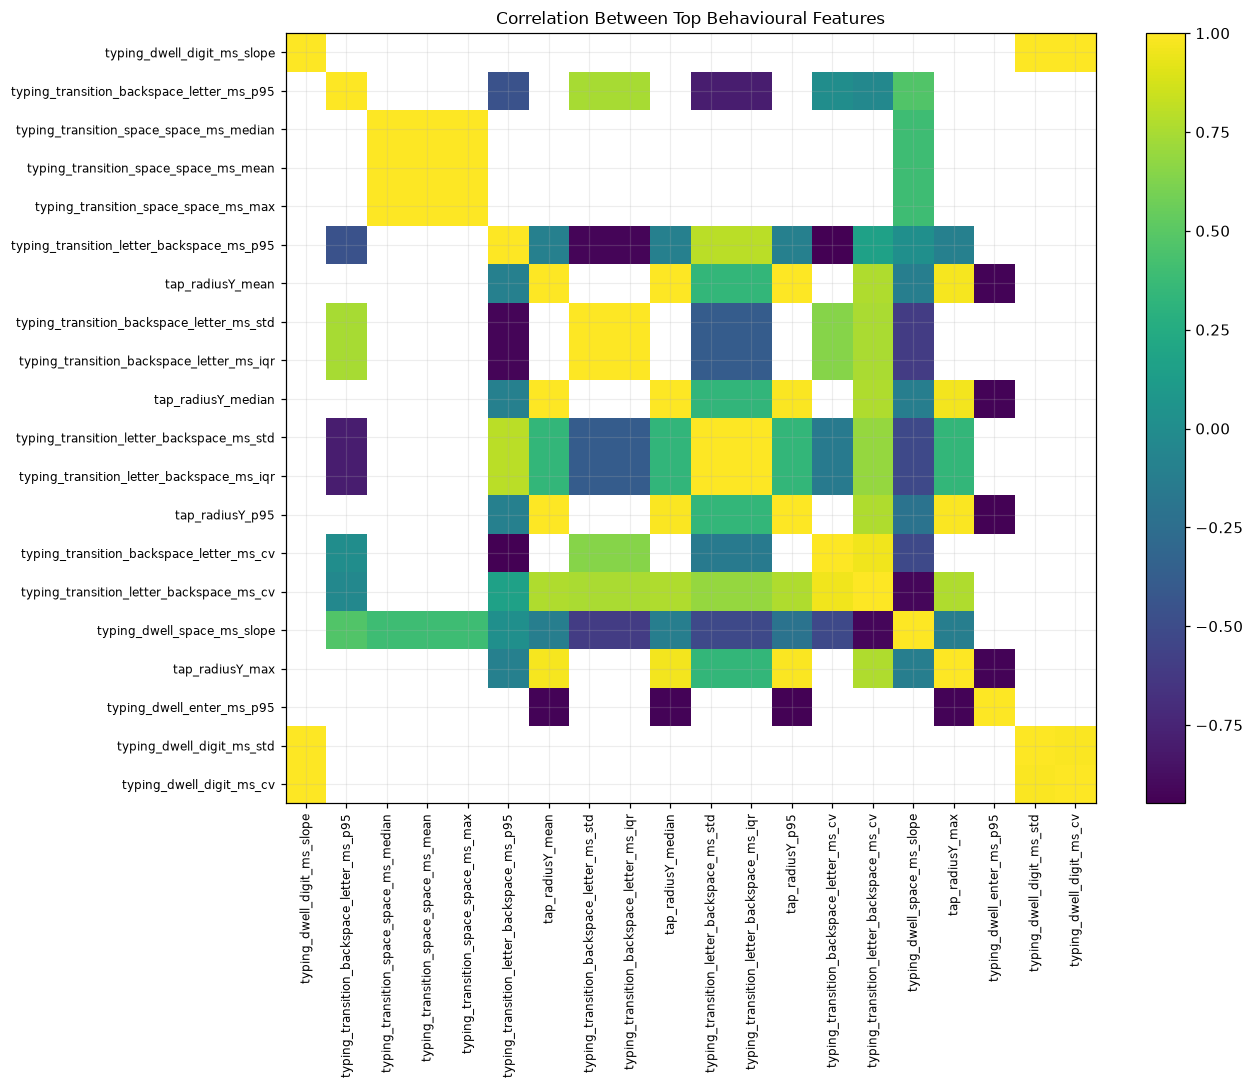

In [53]:
plt.figure(figsize=(12, 10))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr.index)),
    corr.index,
    fontsize=8
)

plt.title("Correlation Between Top Behavioural Features")

plt.tight_layout()
plt.show()

In [54]:
tap_cols = feature_families["tap"]

tap_corr = (
    df[tap_cols]
    .corr()
    .abs()
)

np.fill_diagonal(
    tap_corr.values,
    0
)

high_corr_pairs = (
    tap_corr
    .stack()
    .sort_values(ascending=False)
)

display(high_corr_pairs.head(30))

tap_y_n            tap_count            1.0
tap_x_n            tap_radiusY_n        1.0
tap_radiusY_n      tap_force_n          1.0
tap_hold_ms_n      tap_y_n              1.0
                   tap_radiusX_n        1.0
                   tap_radiusY_n        1.0
tap_count          tap_y_n              1.0
tap_hold_ms_n      tap_force_n          1.0
tap_coverage       tap_cells_touched    1.0
tap_y_n            tap_force_n          1.0
                   tap_radiusY_n        1.0
                   tap_radiusX_n        1.0
tap_force_n        tap_y_n              1.0
                   tap_x_n              1.0
tap_y_n            tap_x_n              1.0
tap_count          tap_radiusX_n        1.0
tap_y_n            tap_hold_ms_n        1.0
tap_force_n        tap_count            1.0
tap_cells_touched  tap_coverage         1.0
tap_count          tap_force_n          1.0
tap_force_n        tap_hold_ms_n        1.0
tap_x_n            tap_force_n          1.0
                   tap_radiusX_n

In [55]:
participant_means = (
    df.groupby("participantId")[feature]
    .mean()
)

In [56]:
device_means = (
    df.groupby("deviceModel")[feature]
    .mean()
)

In [57]:
print("Participant means:")
display(participant_means)

print("\nDevice means:")
display(device_means)

Participant means:


participantId
p3M6E7Z    3.976190
p3YDMHG    3.939940
p95MPVX    3.939130
pA6XL23    3.934426
pAFQRTM    3.969466
pCTJ44P    3.944444
pCURDWC    2.913043
pEAB9GS    3.923077
pEZVKTS    3.920792
pG2C8BC    2.925926
pG5G4MS    3.867257
pH3S4X4    3.957066
pNDG8LJ    3.940299
pUNKH7L    3.645000
pWJGKPK    3.975309
pWS9VTN    3.953488
pZMC82M    3.859649
Name: n_active_modalities, dtype: float64


Device means:


deviceModel
google_pixel_standard        3.920792
iphone_13_13_mini            3.952632
iphone_13_pro_pro_max        3.953488
iphone_15                    3.859649
iphone_16                    3.934426
iphone_16_plus               3.922628
iphone_17e                   3.949686
macbook_trackpad             2.913043
older_iphone                 3.881104
windows_laptop_with_mouse    2.925926
Name: n_active_modalities, dtype: float64

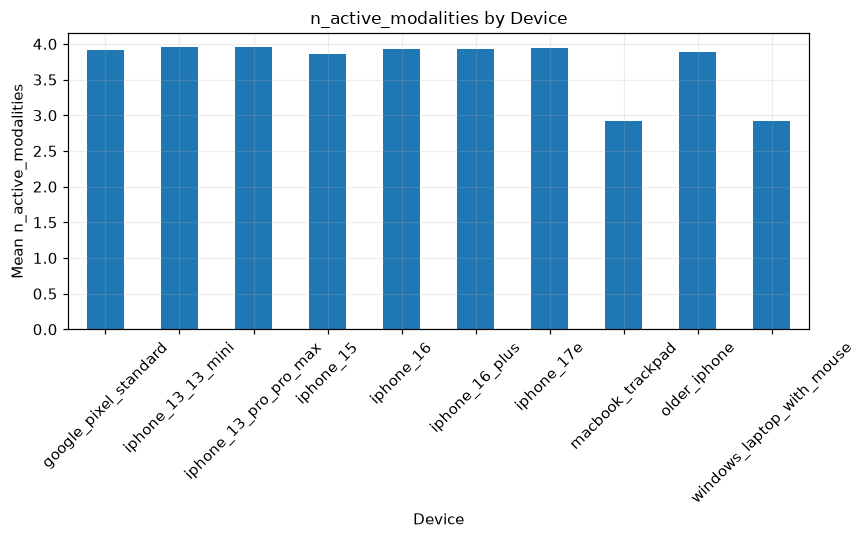

In [58]:
plt.figure(figsize=(8, 5))

device_means.plot(kind="bar")

plt.xlabel("Device")
plt.ylabel(f"Mean {feature}")
plt.title(f"{feature} by Device")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [59]:
user_device_feature = (
    df.groupby(
        ["participantId", "deviceModel"]
    )[feature]
    .agg(["mean", "std", "count"])
)

display(user_device_feature)

,,mean,std,count
participantId,deviceModel,,,
p3M6E7Z,iphone_16_plus,3.976190,0.198566,126
p3YDMHG,iphone_16_plus,3.939940,0.341854,333
p95MPVX,older_iphone,3.939130,0.325645,575
pA6XL23,iphone_16,3.934426,0.357625,122
pAFQRTM,older_iphone,3.969466,0.246169,131
pCTJ44P,older_iphone,3.944444,0.333333,36
pCURDWC,macbook_trackpad,2.913043,0.417029,23
pEAB9GS,iphone_17e,3.923077,0.387105,78
pEZVKTS,google_pixel_standard,3.920792,0.391999,101


In [60]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [61]:
X = df.select_dtypes(
    include=np.number
).copy()

In [62]:
X = X.dropna(
    axis=1,
    how="all"
)

In [63]:
X_imputed = SimpleImputer(
    strategy="median"
).fit_transform(X)

X_scaled = StandardScaler().fit_transform(
    X_imputed
)

In [64]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

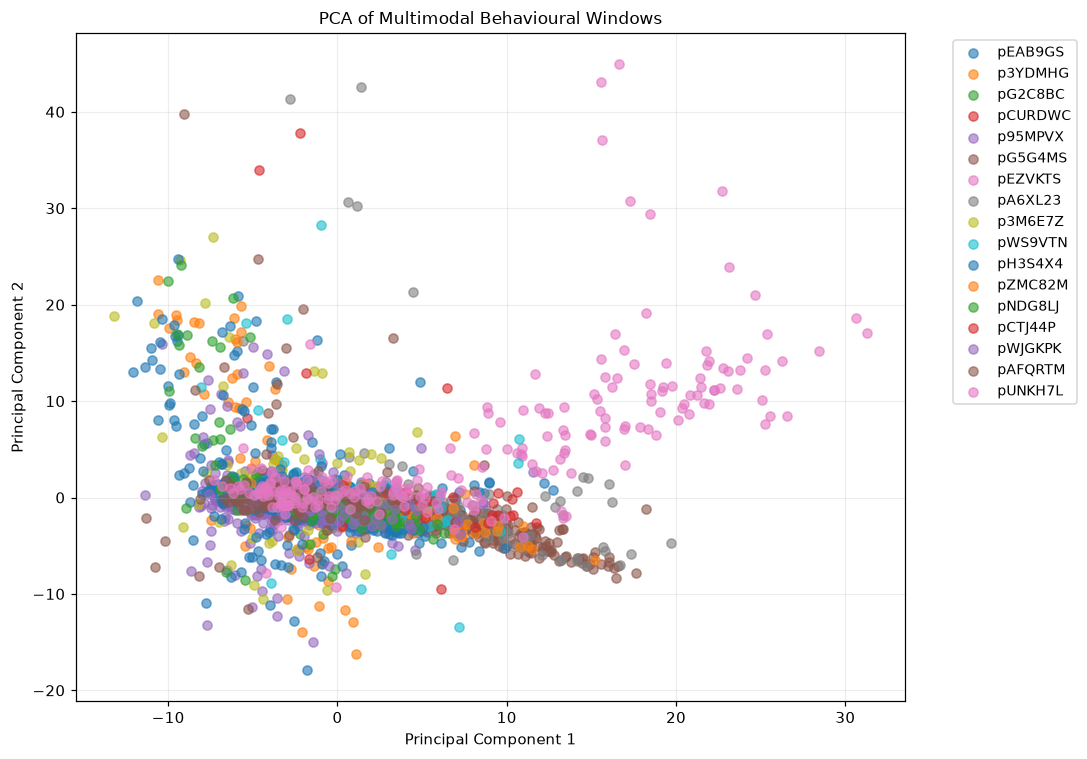

Explained variance: [0.06009808 0.04314166]


In [65]:
plt.figure(figsize=(10, 7))

for participant in df["participantId"].unique():

    mask = (
        df["participantId"] == participant
    )

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        alpha=0.6,
        label=participant
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA of Multimodal Behavioural Windows")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)